In [2]:
import os
if not os.path.exists("~/.kaggle"): # This check is to avoid errors in subsequent runs, you can delete this line.
  !pip install kaggle
  !mkdir ~/.kaggle
  !cp kaggle.json ~/.kaggle/
  !chmod 600 ~/.kaggle/kaggle.json

!kaggle kernels pull priteshshrivastava/covid-19-dataset

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [3]:
# Veri setini indir (dosya zip olarak inecektir)
!kaggle datasets download -d meirnizri/covid19-dataset

Dataset URL: https://www.kaggle.com/datasets/meirnizri/covid19-dataset
License(s): CC0-1.0
100% 4.66M/4.66M [00:00<00:00, 194MB/s]



In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
!unzip covid19-dataset.zip

import pandas as pd
df = pd.read_csv('Covid Data.csv')
df.head()

Archive:  covid19-dataset.zip
  inflating: Covid Data.csv          


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [6]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   USMER                 1048575 non-null  int64 
 1   MEDICAL_UNIT          1048575 non-null  int64 
 2   SEX                   1048575 non-null  int64 
 3   PATIENT_TYPE          1048575 non-null  int64 
 4   DATE_DIED             1048575 non-null  object
 5   INTUBED               1048575 non-null  int64 
 6   PNEUMONIA             1048575 non-null  int64 
 7   AGE                   1048575 non-null  int64 
 8   PREGNANT              1048575 non-null  int64 
 9   DIABETES              1048575 non-null  int64 
 10  COPD                  1048575 non-null  int64 
 11  ASTHMA                1048575 non-null  int64 
 12  INMSUPR               1048575 non-null  int64 
 13  HIPERTENSION          1048575 non-null  int64 
 14  OTHER_DISEASE         1048575 non-null  int64 
 15

In [8]:
print(df.isnull().sum()) # Eksik değer kontrolü

USMER                   0
MEDICAL_UNIT            0
SEX                     0
PATIENT_TYPE            0
DATE_DIED               0
INTUBED                 0
PNEUMONIA               0
AGE                     0
PREGNANT                0
DIABETES                0
COPD                    0
ASTHMA                  0
INMSUPR                 0
HIPERTENSION            0
OTHER_DISEASE           0
CARDIOVASCULAR          0
OBESITY                 0
RENAL_CHRONIC           0
TOBACCO                 0
CLASIFFICATION_FINAL    0
ICU                     0
dtype: int64


In [13]:
df.shape

(1048575, 22)

/tmp/ipykernel_1073/3631527055.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RESULT', data=df, palette='viridis')


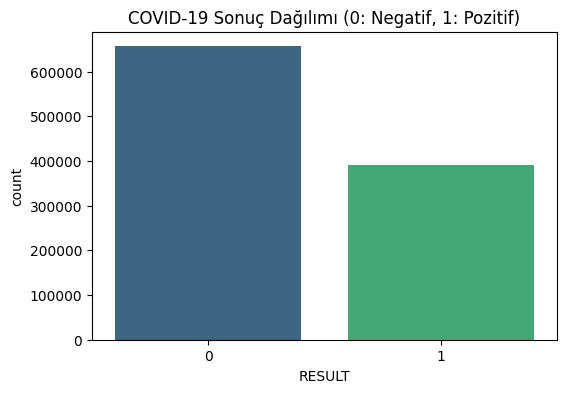

In [10]:
import numpy as np

# Create 'RESULT' column based on 'CLASIFFICATION_FINAL'
# Assuming 1-3 are COVID Positive (1) and 4-7 are COVID Negative (0)
df['RESULT'] = np.where(df['CLASIFFICATION_FINAL'].isin([1, 2, 3]), 1, 0)

plt.figure(figsize=(6,4))
sns.countplot(x='RESULT', data=df, hue='RESULT', palette='viridis', legend=False)
plt.title('COVID-19 Sonuç Dağılımı (0: Negatif, 1: Pozitif)')
plt.show()

In [15]:
# 1. Bilinmeyen kodlarını NaN yapma
cols_to_fix = ['PNEUMONIA', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION',
               'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'INTUBED', 'ICU', 'PREGNANT']

for col in cols_to_fix:
    df[col] = df[col].replace([97, 98, 99], np.nan)

# 2. Temizlik: DATE_DIED sütununu ve NaN satırları silme
df.drop(columns=['DATE_DIED'], inplace=True)
df.dropna(inplace=True)

# 3. Target (Hedef) Oluşturma: CLASIFFICATION_FINAL 1,2,3 -> Pozitif (1), Diğerleri -> Negatif (0)
df['RESULT'] = df['CLASIFFICATION_FINAL'].apply(lambda x: 1 if x <= 3 else 0)
df.drop(columns=['CLASIFFICATION_FINAL'], inplace=True)

print(f"Temizlik Sonrası Boyut: {df.shape}")

Temizlik Sonrası Boyut: (76832, 20)


In [16]:
X = df.drop('RESULT', axis=1)
y = df['RESULT']

# Veriyi %80 Eğitim, %20 Test olarak ayırıyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# --- Model 1: Logistic Regression ---
# Veri büyük olduğu için max_iter değerini yüksek tutuyoruz
lr_model = LogisticRegression(max_iter=2000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# --- Model 2: Random Forest ---
# n_jobs=-1 kullanarak tüm işlemci çekirdeklerini çalıştırıp hızı artırıyoruz
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


==================== Logistic Regression ====================
Accuracy: 0.6237

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.61      0.51      0.56      7130
           1       0.63      0.72      0.67      8237

    accuracy                           0.62     15367
   macro avg       0.62      0.62      0.62     15367
weighted avg       0.62      0.62      0.62     15367



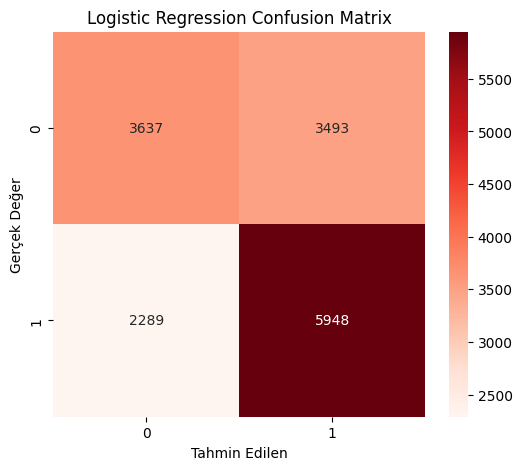


==================== Random Forest ====================
Accuracy: 0.5932

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.57      0.52      0.54      7130
           1       0.61      0.66      0.63      8237

    accuracy                           0.59     15367
   macro avg       0.59      0.59      0.59     15367
weighted avg       0.59      0.59      0.59     15367



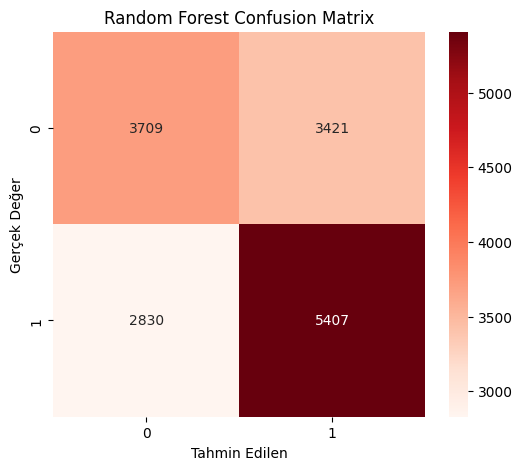

In [18]:
def model_sonuc_yazdir(y_test, y_pred, model_adi):
    print(f"\n{'='*20} {model_adi} {'='*20}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nSınıflandırma Raporu:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix (Karmaşıklık Matrisi)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
    plt.title(f'{model_adi} Confusion Matrix')
    plt.ylabel('Gerçek Değer')
    plt.xlabel('Tahmin Edilen')
    plt.show()

model_sonuc_yazdir(y_test, lr_pred, "Logistic Regression")
model_sonuc_yazdir(y_test, rf_pred, "Random Forest")

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# --- Model 3: Decision Tree (Karar Ağacı) ---
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# --- Model 4: KNN (K-Nearest Neighbors) ---
# UYARI: Veri seti çok büyükse KNN saatler sürebilir.
# Eğer hata alırsan veya çok bekletirse bu kısmı atlayabilirsin.
knn_model = KNeighborsClassifier(n_neighbors=5)
# KNN için verinin sadece ilk 10.000 satırını kullanarak test edebilirsin:
knn_model.fit(X_train[:10000], y_train[:10000])
knn_pred = knn_model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "Decision Tree": dt_pred,
    "KNN": knn_pred
}

performance_list = []

for name, pred in models.items():
    performance_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-Score": f1_score(y_test, pred)
    })

# Karşılaştırma Tablosu
perf_df = pd.DataFrame(performance_list)
print(perf_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.623739   0.630018  0.722108  0.672927
1        Random Forest  0.593219   0.612483  0.656428  0.633695
2        Decision Tree  0.578903   0.608664  0.600461  0.604535
3                  KNN  0.573046   0.596013  0.631541  0.613263
